# Beyond RAG — GEMS-RAG pipeline (Colab)

Graph-grounded multimodal retrieval over the MUTCD 11th Edition, plus the
MUTCD-150 benchmark runner and ablation harness.

**Run order.** Sections 0–2 once per session. Section 3 onwards is optional.

**Before you start:**
1. Runtime -> Change runtime type -> **A100 GPU**
2. Put the MUTCD PDF in `Drive/MyDrive/MRAG/` (any `*.pdf` filename works)
3. Add API keys under the key icon in the left sidebar (Colab Secrets)

First run does a full ingest (~30–45 min on A100). Later sessions restore a
Qdrant snapshot from Drive in about 30 seconds.


## 0. Setup

In [1]:
# COLAB ONLY — skip this cell if running on HPRC.
import sys, os

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ── WHERE EVERYTHING LIVES ─────────────────────────────────────────────────
# Data (PDF, cache, figures, page images, HF cache, snapshots, runs) lives on
# Drive. The repo is cloned to local disk and is disposable.
#
# MRAG_BASE_DIR overrides the default in config.py. It must be set BEFORE any
# mrag import, and it must be an env var so subprocesses (ingest_v4.py, run via
# !python) inherit it — sys.modules detection does not cross process boundaries.
DRIVE_DIR = "/content/drive/MyDrive/Beyond_RAG"       # <- data on Drive
REPO_DIR  = "/content/Beyond_RAG_repo"                # <- code, local, disposable
REPO_URL  = "https://github.com/hannanazad/Beyond_RAG.git"

os.environ["MRAG_ENV"]      = "colab"
os.environ["MRAG_BASE_DIR"] = DRIVE_DIR
os.makedirs(DRIVE_DIR, exist_ok=True)

if not os.path.isdir(REPO_DIR):
    !git clone $REPO_URL $REPO_DIR
else:
    !cd $REPO_DIR && git pull

sys.path.insert(0, REPO_DIR)
print(f"\ndata : {DRIVE_DIR}")
print(f"code : {REPO_DIR}")

# Step 1 — torch matched to Colab's CUDA 12.4.
# Colab ships torch 2.5.1, but transformers >=4.51 enforces CVE-2025-32434 and
# refuses to load .bin checkpoints on torch <2.6. BGE-M3 ships .bin.
!pip install -q --index-url https://download.pytorch.org/whl/cu124 \
    torch==2.6.0 torchvision==0.21.0

# Step 2 — everything else
!pip install -q -r $REPO_DIR/requirements.txt

# Step 3 — pip's bulk resolver does not enforce CEILINGS when an installed
# version already satisfies the lower bound. Colab ships newer packages than
# this pipeline can use, so pin them explicitly.
!pip install -q --no-deps --force-reinstall \
    "transformers>=4.49,<4.55" \
    "huggingface_hub>=0.34,<0.35" \
    "tokenizers>=0.21,<0.22" \
    "torchao>=0.13,<0.14"

!python -c "from transformers import PreTrainedModel; print('transformers import OK')"

Mounted at /content/drive
Cloning into '/content/Beyond_RAG'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 127 (delta 29), reused 127 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 4.73 MiB | 23.29 MiB/s, done.
Resolving deltas: 100% (29/29), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 138.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 92.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 171.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 74.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 81.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 112.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127

In [24]:
# API keys from Colab Secrets (key icon, left sidebar).
# Keys authenticate only; select the model with CFG.set_vlm_model(...).
from google.colab import userdata
import os

def _load(env_name, *secret_names):
    for s in secret_names:
        try:
            os.environ[env_name] = userdata.get(s)
            print(f"{env_name}: loaded (secret {s!r})")
            return
        except Exception:
            continue
    print(f"{env_name}: no matching secret (skipped)")

_load("DASHSCOPE_API_KEY", "DASHSCOPE_API_KEY", "QWEN")
_load("ANTHROPIC_API_KEY", "ANTHROPIC_API_KEY")
_load("GEMINI_API_KEY",    "GEMINI_API_KEY")

DASHSCOPE_API_KEY: loaded (secret 'DASHSCOPE_API_KEY')
ANTHROPIC_API_KEY: loaded (secret 'ANTHROPIC_API_KEY')
GEMINI_API_KEY: no matching secret (skipped)


### 0.1 Moving from `Drive/MyDrive/MRAG`

If you already ingested into the old `MRAG` folder, move it rather than
re-ingesting — that saves 45 minutes and the ColQwen page vectors.

**Fastest way: rename it in the Drive web UI.** Right-click `MRAG` → Rename →
`Beyond_RAG`. Instant, because Drive renames server-side.

The cell below only checks where things stand. It does not move anything.

In [ ]:
import os
from pathlib import Path

old = Path("/content/drive/MyDrive/MRAG")
new = Path(os.environ["MRAG_BASE_DIR"])

def survey(p):
    if not p.exists():
        return "does not exist"
    bits = []
    for name in ("mmrag_cache_v3", "figures", "page_images", "hf_cache"):
        d = p / name
        bits.append(f"{name}={'yes' if d.exists() else 'no'}")
    pdfs = list(p.glob("*.pdf"))
    bits.append(f"pdf={pdfs[0].name if pdfs else 'MISSING'}")
    bits.append(f"snapshot={'yes' if (p/'qdrant_db.tar').exists() else 'no'}")
    return "  ".join(bits)

print(f"OLD  {old}\n     {survey(old)}\n")
print(f"NEW  {new}\n     {survey(new)}\n")

if old.exists() and not (new / "mmrag_cache_v3").exists():
    print("ACTION: rename MRAG -> Beyond_RAG in the Drive web UI, then re-run cell 0.")
    print("        Copying through Colab works but is slow — page_images alone is ~3 GB.")
elif (new / "mmrag_cache_v3").exists():
    print("Beyond_RAG already holds the cache. Nothing to do.")
else:
    print("Neither folder has a cache. Upload the MUTCD PDF to Beyond_RAG and ingest.")

## 1. Sanity check

In [3]:
import os, sys
REPO_DIR = "/content/Beyond_RAG_repo"
sys.path.insert(0, REPO_DIR if os.path.isdir(REPO_DIR) else ".")

from mrag.config import CFG

print("Environment :", CFG.environment)
print("Base dir    :", CFG.base_dir, "| exists:", CFG.base_dir.exists())
print("PDF path    :", CFG.pdf_path, "| exists:", CFG.pdf_path.exists())
print("Cache dir   :", CFG.cache_dir)
print("Qdrant dir  :", CFG.qdrant_dir, "  (local SSD, snapshotted to Drive)")
print("HF cache    :", CFG.hf_home)
print("VLM provider:", CFG.vlm_provider)
print("VLM model   :", CFG.vlm_model_api if CFG.vlm_provider == "api" else CFG.vlm_model)
print("API key set :", bool(os.environ.get(CFG.api_key_env_var)))
print()
print("Image budget: max_sheets_per_figure =", CFG.max_sheets_per_figure,
      "| max_images_total =", CFG.max_images_total,
      "| max_page_images =", CFG.max_page_images)

assert str(CFG.base_dir).endswith("Beyond_RAG"), \
    f"base_dir is {CFG.base_dir} — MRAG_BASE_DIR did not take. Re-run cell 0."

try:
    import torch
    print("GPU         :", torch.cuda.get_device_name(0))
except Exception as e:
    print("GPU         : none —", e)

assert CFG.pdf_path.exists(), (
    f"No PDF at {CFG.pdf_path} or anywhere in {CFG.base_dir}. "
    f"Upload the MUTCD PDF there first."
)

Environment : colab
Base dir    : /content/drive/MyDrive/MRAG | exists: True
PDF path    : /content/drive/MyDrive/MRAG/mutcd11theditionr1hl.pdf | exists: True
Qdrant dir  : /content/qdrant_db
Cache dir   : /content/drive/MyDrive/MRAG/mmrag_cache_v3
HF cache    : /content/drive/MyDrive/MRAG/hf_cache
VLM provider: api
VLM model   : qwen3-vl-plus-2025-12-19
API key set : False

Sheets per figure : 8
Images per request: 12
GPU         : NVIDIA A100-SXM4-40GB


## 2. Build or restore the vector store

Restores a Drive snapshot if one exists and the figure crops are v4.
Otherwise runs a full ingest.


In [4]:
import shutil, tarfile, json
from pathlib import Path
from qdrant_client import QdrantClient

local_qdrant     = CFG.qdrant_dir                  # /content/qdrant_db (fast local SSD)
drive_qdrant_tar = CFG.base_dir / "qdrant_db.tar"  # snapshot on Drive

def _qdrant_ok(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        c = QdrantClient(path=str(path))
        try:
            return CFG.coll_chunks in {col.name for col in c.get_collections().collections}
        finally:
            c.close()
    except Exception:
        return False

def _v4_done() -> bool:
    """True once v4 (caption-below) figure extraction has run."""
    try:
        with open(CFG.figures_jsonl) as f:
            first = json.loads(next(f))
        return str(first.get("extraction_method", "")).startswith("caption_below_v2")
    except Exception:
        return False

if _qdrant_ok(local_qdrant) and _v4_done():
    print(f"Qdrant populated at {local_qdrant} and figures are v4. Nothing to do.")

elif drive_qdrant_tar.exists() and _v4_done():
    print(f"Restoring snapshot from {drive_qdrant_tar} "
          f"({drive_qdrant_tar.stat().st_size/1e6:.0f} MB)...")
    shutil.rmtree(local_qdrant, ignore_errors=True)
    local_qdrant.mkdir(parents=True, exist_ok=True)
    with tarfile.open(drive_qdrant_tar, "r") as tar:
        tar.extractall(local_qdrant.parent)
    assert _qdrant_ok(local_qdrant), "Extracted but collection not found."
    print("Local Qdrant verified OK.")

else:
    if drive_qdrant_tar.exists() and not _v4_done():
        print("Snapshot on Drive is stale (figures are pre-v4) — ignoring it.")
    else:
        print("No usable store found. Running ingest.")
    print("Expect ~30-45 min on an A100. Run the snapshot cell afterwards.")
    !cd /content/Beyond_RAG && python scripts/ingest_v4.py
    assert _qdrant_ok(local_qdrant), "Ingest finished but Qdrant is empty — check the log."
    assert _v4_done(),               "Ingest ran but figures.jsonl is not v2 — check the log."
    print("Ingest verified OK.")

Restoring snapshot from /content/drive/MyDrive/MRAG/qdrant_db.tar (1571 MB)...


/tmp/ipykernel_1690/3255620005.py:38: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_qdrant.parent)


Local Qdrant verified OK.


### 2.1 Snapshot Qdrant back to Drive

Run after any successful ingest so the next session restores in seconds.

In [5]:
if CFG.environment == "colab":
    local_qdrant     = CFG.qdrant_dir
    drive_qdrant_tar = CFG.base_dir / "qdrant_db.tar"

    if local_qdrant.exists():
        print(f"Snapshotting {local_qdrant} -> {drive_qdrant_tar} ...")
        drive_qdrant_tar.parent.mkdir(parents=True, exist_ok=True)
        with tarfile.open(drive_qdrant_tar, "w") as tar:
            tar.add(local_qdrant, arcname=local_qdrant.name)
        print(f"Done ({drive_qdrant_tar.stat().st_size/1e6:.0f} MB).")
    else:
        print("No local Qdrant to snapshot.")

Snapshotting /content/qdrant_db -> /content/drive/MyDrive/MRAG/qdrant_db.tar ...
Done (1571 MB).


### 2.2 Repair colliding chunk IDs

`chunk_id` is `section + rule_type + ordinal`, which is **not unique**: a
paragraph split across a page break re-fires the ordinal. 36 IDs collided
across 107 rows, and because Qdrant upserts by `chunk_id_to_int(chunk_id)`,
the later row silently overwrote the earlier one.

`parsing.py` now suffixes repeats, so a **fresh ingest** is already fixed.
This cell repairs an **existing cache** without re-embedding — the dense
vectors for all rows already exist in file order, so only the IDs change.

Report first, then re-run with `--apply`, then rebuild the graph and
re-upsert.


In [7]:
# Report only — nothing is written.
!cd /content/Beyond_RAG && python scripts/repair_chunk_ids.py --cache "$(python -c 'from mrag.config import CFG; print(CFG.cache_dir)')"

# To actually rewrite chunks.jsonl (a .prerepair.bak is kept), uncomment:
!cd /content/Beyond_RAG && python scripts/repair_chunk_ids.py --cache "$(python -c 'from mrag.config import CFG; print(CFG.cache_dir)')" --apply

rows in chunks.jsonl : 5812
unique ids before    : 5705
unique ids after     : 5812
chunks recovered     : 107
ids rewritten        : 107  (all others untouched)
chunks_dense.npy rows: 5812  ->  aligned: True

most-collided ids:
  MUTCD11e_2L06_Option_01  x17
  MUTCD11e_2L06_Option_02  x17
  MUTCD11e_2D07_Guidance_06  x13
  MUTCD11e_2D07_Guidance_08  x10
  MUTCD11e_2D07_Guidance_10  x8

report only -- pass --apply to rewrite chunks.jsonl
rows in chunks.jsonl : 5812
unique ids before    : 5705
unique ids after     : 5812
chunks recovered     : 107
ids rewritten        : 107  (all others untouched)
chunks_dense.npy rows: 5812  ->  aligned: True

most-collided ids:
  MUTCD11e_2L06_Option_01  x17
  MUTCD11e_2L06_Option_02  x17
  MUTCD11e_2D07_Guidance_06  x13
  MUTCD11e_2D07_Guidance_08  x10
  MUTCD11e_2D07_Guidance_10  x8

backup written: /content/drive/MyDrive/MRAG/mmrag_cache_v3/chunks.prerepair.bak.jsonl
rewrote /content/drive/MyDrive/MRAG/mmrag_cache_v3/chunks.jsonl with 5812 unique i

## 3. Initialise the pipeline

In [8]:
import logging, os
logging.basicConfig(level=logging.INFO, format='%(name)s - %(message)s')

if CFG.vlm_provider == "api" and not os.environ.get(CFG.api_key_env_var):
    print(f"NOTE: no key in {CFG.api_key_env_var!r} for {CFG.vlm_model_api!r}. "
          f"Init will proceed; load the key or switch with CFG.set_vlm_model(...).")

from mrag.ask import init_pipeline
pipeline = init_pipeline()
print("VLM loaded :", pipeline.vlm.loaded_name if pipeline.vlm else "none")
print("KG         :", pipeline.kg.g.number_of_nodes(), "nodes,",
                      pipeline.kg.g.number_of_edges(), "edges")

NOTE: no key in 'VLM_API_KEY' for 'qwen3-vl-plus-2025-12-19'. Init will proceed; load the key or switch with CFG.set_vlm_model(...).


/usr/local/lib/python3.13/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


VLM loaded : qwen3-vl-plus-2025-12-19
KG         : 8240 nodes, 18245 edges


In [9]:
# ── List every VLM the config knows about, grouped by provider ──────────────
import os
from mrag.config import (
    CFG, VLM_API_MODELS, VLM_PROVIDERS, provider_of_model,
    VLM_TEXT_ONLY_ALIASES, VLM_VISION_UNVERIFIED,
)

# key present?  ->  can you actually call it
have_key = {p: bool(os.environ.get(v["env_var"])) for p, v in VLM_PROVIDERS.items()}
print("API keys loaded:", {p: ("yes" if k else "NO") for p, k in have_key.items()})
print("Currently selected:", CFG.vlm_model_api, f"[{provider_of_model(CFG.vlm_model_api)}]")
print()

# one row per distinct model id, collecting the aliases that point at it
by_model = {}
for alias, mid in VLM_API_MODELS.items():
    by_model.setdefault(mid, []).append(alias)

for prov in ("anthropic", "gemini", "dashscope"):
    rows = [(m, a) for m, a in by_model.items() if provider_of_model(m) == prov]
    if not rows:
        continue
    print(f"── {prov.upper()}   (key: {'yes' if have_key[prov] else 'NO'})")
    for mid, aliases in sorted(rows):
        flags = []
        if mid in VLM_VISION_UNVERIFIED:
            flags.append("VISION UNVERIFIED")
        if any(a in VLM_TEXT_ONLY_ALIASES for a in aliases):
            flags.append("TEXT ONLY - will 400 on images")
        if mid == CFG.vlm_model_api:
            flags.append("<< SELECTED")
        note = ("   " + " | ".join(flags)) if flags else ""
        print(f"   {'  '.join(sorted(aliases)):<42} -> {mid}{note}")
    print()

print("Select with:  CFG.set_vlm_model('fast_claude')")
print("A raw model id works too:  CFG.set_vlm_model('claude-sonnet-5')")

API keys loaded: {'dashscope': 'yes', 'anthropic': 'yes', 'gemini': 'NO'}
Currently selected: qwen3-vl-plus-2025-12-19 [dashscope]

── ANTHROPIC   (key: yes)
   fable  frontier_claude                     -> claude-fable-5
   fast_claude  haiku                         -> claude-haiku-4-5-20251001
   balanced_claude  sonnet                    -> claude-sonnet-5

── GEMINI   (key: NO)
   fast_gemini  gemini-flash-lite             -> gemini-3.1-flash-lite
   frontier_gemini  gemini-pro                -> gemini-3.1-pro-preview
   balanced_gemini  gemini-flash              -> gemini-3.5-flash

── DASHSCOPE   (key: yes)
   glm-5.2                                    -> glm-5.2   TEXT ONLY - will 400 on images
   kimi-k2.7-code                             -> kimi-k2.7-code   TEXT ONLY - will 400 on images
   max                                        -> qwen-vl-max
   qwen-vl-plus                               -> qwen-vl-plus
   qwen2.5-vl                                 -> qwen2.5-vl-72b-instr

In [10]:
# ── Pick a model ────────────────────────────────────────────────────────────
resolved = CFG.set_vlm_model("frontier_qwen")      # cheap, for smoke tests

print("model    :", resolved)
print("provider :", provider_of_model(resolved))
print("key set  :", bool(os.environ.get(CFG.api_key_env_var)), f"({CFG.api_key_env_var})")

# The pipeline reads CFG at call time, so no re-init needed.
#_ = ask("What shape and colour is a STOP sign?")

model    : qwen3.7-max-2026-06-08
provider : dashscope
key set  : True (DASHSCOPE_API_KEY)


## 4. Ask

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


### Q
What is required when installing a STOP sign at an all-way stop intersection?

### Answer

Direct Answer: When installing a STOP sign at an all-way stop intersection, the sign must be placed on the near side of the intersection on the right-hand side of the approach. An ALL-WAY supplemental plaque is mandatory below each STOP sign. If sign visibility is restricted at this required location, a Stop Ahead sign must be installed in advance.

Standards (mandatory):
- The STOP or YIELD sign shall be installed on the near side of the intersection on the right-hand side of the approach to which it applies.
- At intersections where all approaches are controlled by STOP signs, an ALL-WAY (R1-3P) supplemental plaque shall be mounted below each STOP sign. The ALL-WAY plaque shall have a white legend and border on a red background.
- When the STOP or YIELD sign is installed at this required location and the sign visibility is restricted, a Stop Ahead sign shall be installed in advance of the STOP sign.

Options (permitted):
- All-way stop control may be installed at an intersection where an engineering study indicates that sight distance on the minor-road approaches is not adequate.
- All-way stop control may be installed at an intersection where an engineering study indicates specific volume thresholds (combined volume entering from major-street approaches is at least 300 units per hour and minor-street approaches is at least 200 units per hour for any 8 hours).
- All-way stop control may be installed at an intersection where an engineering study indicates specific crash experience (five or more reported crashes in a 12-month period for a four-leg intersection, or four or more for a three-leg intersection).
- All-way stop control may be installed at an intersection where an engineering study indicates other factors such as the need to control left-turn conflicts or pedestrian/bicyclist movements.

Visual evidence: Figure 2B-1 displays the standard STOP sign (R1-1) and the ALL WAY plaque (R1-3P) which features a red background with a white legend and border.

Citations:
- Section 2B.18 Standard §1 (p.79)
- Section 2B.04 Standard §4 (p.74)
- Section 2B.14 Option §1 (p.79)
- Section 2B.16 Option §1 (p.79)
- Section 2B.13 Option §1 (p.79)
- Section 2B.17 Option §1 (p.79)
- Figure 2B-1 (p.74)

### Figures the model saw

**[Image 1]** Figure 2B-1 (p.74) — depicts R1-1, R1-10P, R1-2, R1-3P, W4-4AP, W4-4BP, W4-4P  
*Figure 2B-1. STOP and YIELD Signs and Plaques*

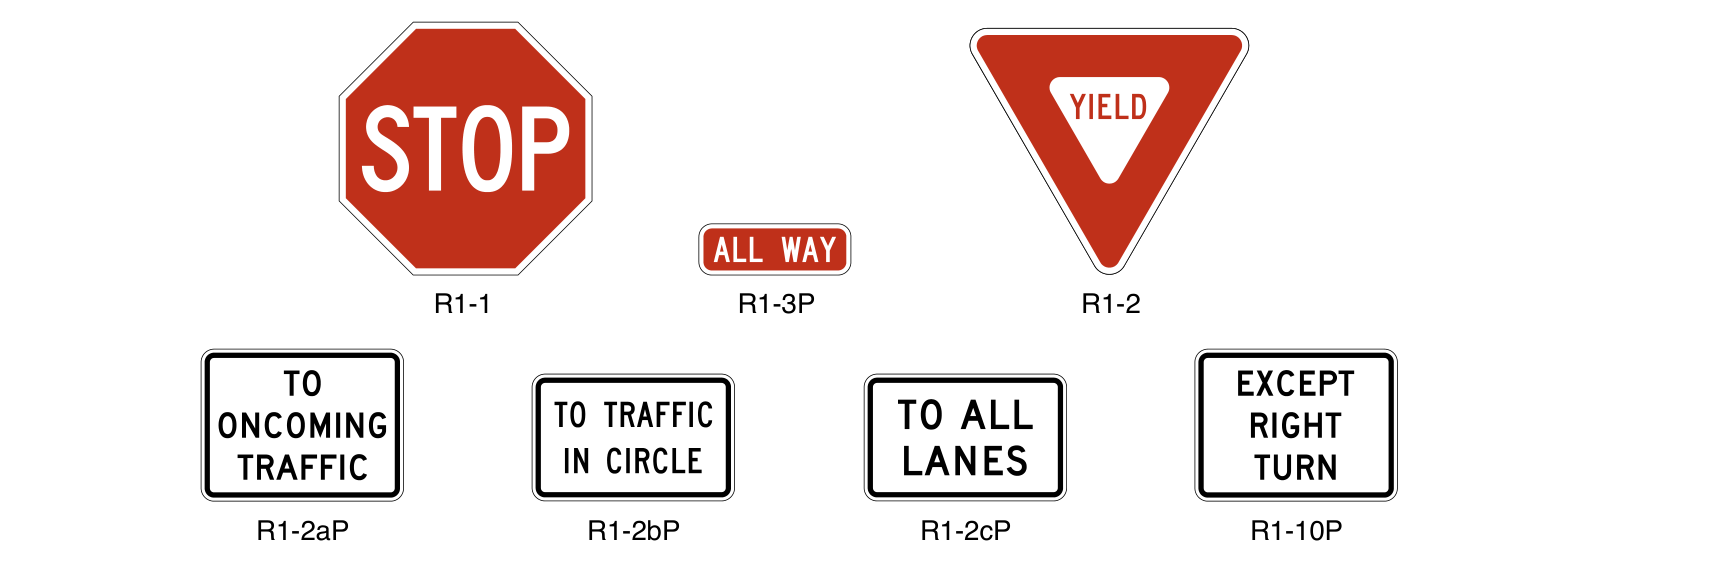

In [11]:
from mrag.ask import ask

_ = ask("What is required when installing a STOP sign at an all-way stop intersection?")

### Q
Explain Figure 2B-1 and the plaques it shows

### Answer

Direct Answer: Figure 2B-1 displays the standard STOP (R1-1) and YIELD (R1-2) signs along with several supplemental plaques used with them. These plaques include the ALL WAY (R1-3P), TO ONCOMING TRAFFIC (R1-2aP), TO TRAFFIC IN CIRCLE (R1-2bP), TO ALL LANES (R1-2cP), and EXCEPT RIGHT TURN (R1-10P) plaques.

Standards (mandatory):
- At intersections where all approaches are controlled by STOP signs, an ALL-WAY (R1-3P) supplemental plaque shall be mounted below each STOP sign. The ALL-WAY plaque shall have a white legend and border on a red background.

Options (permitted):
- The EXCEPT RIGHT TURN (R1-10P) plaque may be mounted below the STOP sign if an engineering study determines that a special combination of geometry and traffic volumes is present that makes it possible for right-turning traffic on the approach to be allowed to enter the intersection without stopping.

Visual evidence:
- Figure 2B-1 shows the red octagonal STOP sign (R1-1), the red inverted triangle YIELD sign (R1-2), the red ALL WAY plaque (R1-3P), and four white rectangular plaques: TO ONCOMING TRAFFIC (R1-2aP), TO TRAFFIC IN CIRCLE (R1-2bP), TO ALL LANES (R1-2cP), and EXCEPT RIGHT TURN (R1-10P).

Citations:
- Section 2B.04 Standard §4 (p.74)
- Section 2B.04 Option §8 (p.74)
- Figure 2B-1 (p.74)

### Figures the model saw

**[Image 1]** Figure 2B-1 (p.74) — depicts R1-1, R1-10P, R1-2, R1-3P, W4-4AP, W4-4BP, W4-4P  
*Figure 2B-1. STOP and YIELD Signs and Plaques*  
score=0.000

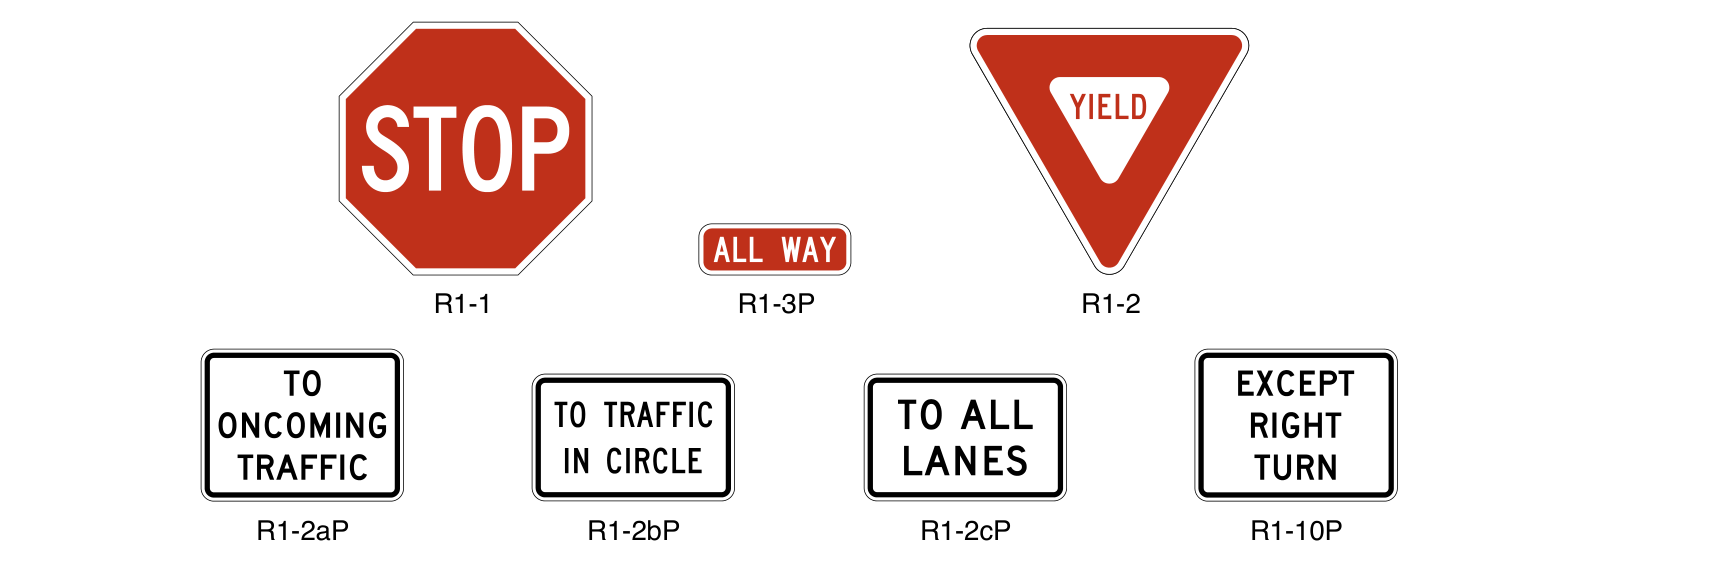

In [12]:
_ = ask("Explain Figure 2B-1 and the plaques it shows", show_scores=True)

In [13]:
# Router smoke test: a definitional question should retrieve NO figures.
# Check the debug output — figure_router.needs_figures should be False.
_ = ask("What does 'shall' mean in the MUTCD?", show_scores=True)

### Q
What does 'shall' mean in the MUTCD?

### Answer

Direct Answer: In the MUTCD, the word "shall" is used to denote a Standard, which represents a required, mandatory, or specifically prohibitive practice regarding a traffic control device. It is typically used in Standard statements and is never used in Guidance or Option statements.

Standards (mandatory):
- "Standard-a statement of required, mandatory, or specifically prohibitive practice regarding a traffic control device."
- "The verb “shall” is typically used. The verbs “should” and “may” are not used in Standard statements."

Citations:
- Section 1C.01 Standard §1 (p.13)

## 5. Verify the multi-sheet figure fix

A canonical MUTCD figure or table can span several sheets. Retrieval always
emitted every sheet in `image_paths`, but the prompt builder read the
singular `image_path` — so **only sheet 1 ever reached the model**.

116 of 553 canonical entities are multi-sheet, hiding 174 sheets. 34 of the
150 benchmark questions have gold evidence on one of them. Table 2B-1 has
8 sheets and is the gold evidence for TB008, TB009 and TB026.


In [14]:
import json, collections
figs = [json.loads(l) for l in open(CFG.figures_jsonl) if l.strip()]
canon = collections.defaultdict(list)
for f in figs:
    canon[(f["kind"], f["canonical_id"])].append(f)      # key on BOTH — ids collide across kinds

multi = {k: v for k, v in canon.items() if len(v) > 1}
print(f"canonical entities : {len(canon)}")
print(f"multi-sheet        : {len(multi)}")
print(f"sheets beyond first: {sum(len(v) - 1 for v in multi.values())}")
print(f"widest             : {sorted(((len(v), k[1]) for k, v in multi.items()), reverse=True)[:5]}")
print()
print(f"caps: sheets/figure={CFG.max_sheets_per_figure}  "
      f"images/request={CFG.max_images_total}  pages reserved={CFG.max_page_images}")
covered = sum(1 for v in canon.values() if len(v) <= CFG.max_sheets_per_figure)
print(f"entities fully shown under the per-figure cap: {covered}/{len(canon)}")

# ── allocation check ───────────────────────────────────────────────────────
# Selection is ROUND-ROBIN: sheet 1 of every figure, then sheet 2 of every
# figure, and so on. Greedy allocation let one 8-sheet table eat the budget and
# starve later figures, which cost more than it gained (TB009 went from full
# credit to abstaining). Every retrieved figure must keep at least sheet 1.
def simulate(sheet_counts, cap=None, per_fig=None, pages=1, reserve=None):
    cap     = cap or CFG.max_images_total
    per_fig = per_fig or CFG.max_sheets_per_figure
    reserve = CFG.max_page_images if reserve is None else reserve
    per = [list(range(min(n, per_fig))) for n in sheet_counts]
    budget = max(0, cap - min(pages, reserve))
    picked, depth = [], 0
    while len(picked) < budget and any(len(s) > depth for s in per):
        for fi, s in enumerate(per):
            if depth < len(s) and len(picked) < budget:
                picked.append((fi, depth))
        depth += 1
    shown = len({fi for fi, _ in picked})
    return len(picked), shown, len(sheet_counts)

for label, counts in [("TB009-like: 8-sheet table + 2 figures", [8, 6, 3]),
                      ("one 8-sheet table alone",               [8]),
                      ("five single-sheet figures",             [1, 1, 1, 1, 1])]:
    n, shown, total = simulate(counts)
    ok = "OK" if shown == total else "STARVED"
    print(f"  {label:<40} {n:>2} imgs, {shown}/{total} figures  {ok}")

canonical entities : 553
multi-sheet        : 116
sheets beyond the first: 174
widest: [(8, ('Table', '2B-1')), (7, ('Figure', '3B-11')), (5, ('Table', '2C-1')), (5, ('Figure', '2C-3')), (5, ('Figure', '2C-13'))]

cap in use: max_sheets_per_figure=8, max_images_total=12
entities fully shown under the cap: 553/553


### Q
What are the required sign sizes in Table 2B-1 for a STOP sign?

### Answer

Direct Answer: According to Table 2B-1, the STOP sign (R1-1) has a minimum size of 30 x 30 inches for single-lane conventional roads and low-volume rural roads with operating speeds of 30 mph or less. For multi-lane conventional roads and expressways, the required minimum size is 36 x 36 inches. An oversized version of 48 x 48 inches is also provided in the table.

Standards (mandatory):
- Except as provided in Section 2A.07, the minimum sizes for regulatory signs shall be as shown in Table 2B-1.

Visual evidence:
- Table 2B-1 lists the STOP sign (R1-1) sizes as 30 x 30 inches for the Single Lane and Minimum columns, 36 x 36 inches for the Multi-Lane and Expressway columns, and 48 x 48 inches for the Oversized column. [Image 2]

Citations:
- Section 2B.03 Standard §1 (p.67)
- Table 2B-1 (p.67)

### Figures the model saw

**[Image 1]** Table 2B-1 (p.67) — depicts R1-1, R1-2, R1-2AP, R1-7, R1-7A, R1-8, R10-11, R10-11A, R10-11B, R10-17A, R10-6, R11-2, R11-3, R12-1, R12-5, R2-1, R2-10, R2-11, R2-12, R2-6AP, R2-6BP, R2-6P, R22-2, R3-1, R3-18, R3-27, R3-5, R3-6, R3-7, R3-8, R4-1, R4-2, R4-7, R4-7C, R4-9, R4-9A, R5-1, R5-1A, R6-1, R6-2, R8-3, R9-10, R9-11, R9-11A, R9-12, R9-8, R9-9  
*Table 2B-1.*  
score=0.000

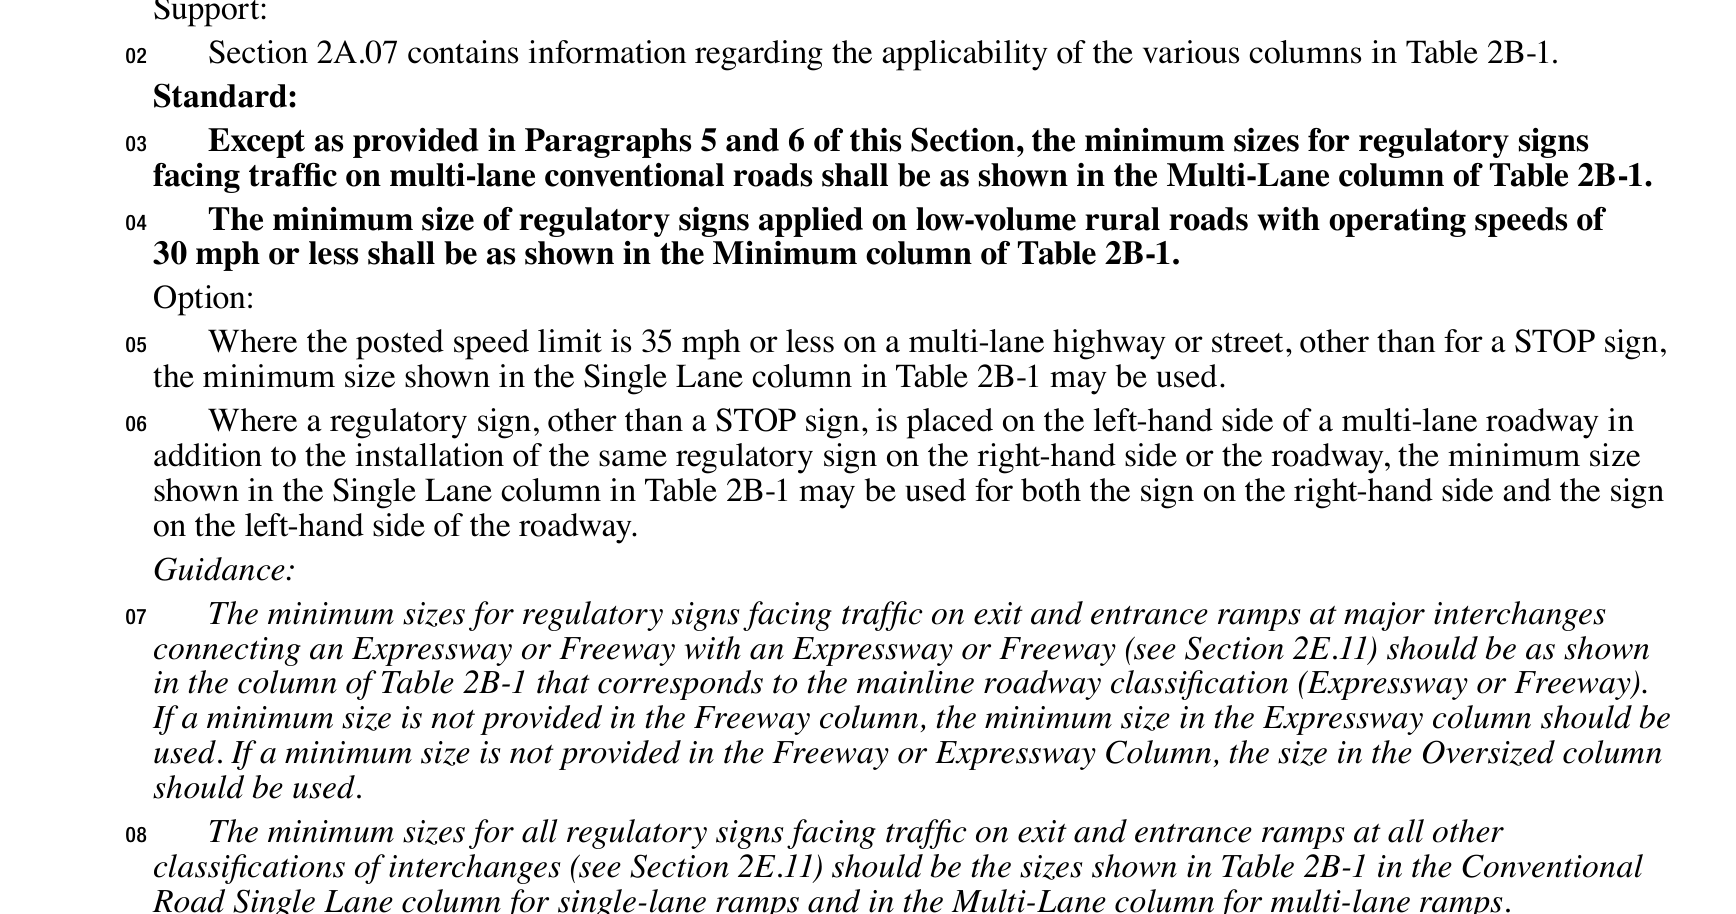

**[Image 2]** Figure 2B-1 (p.74) — depicts R1-1, R1-10P, R1-2, R1-3P, W4-4AP, W4-4BP, W4-4P  
*Figure 2B-1. STOP and YIELD Signs and Plaques*  
score=0.000

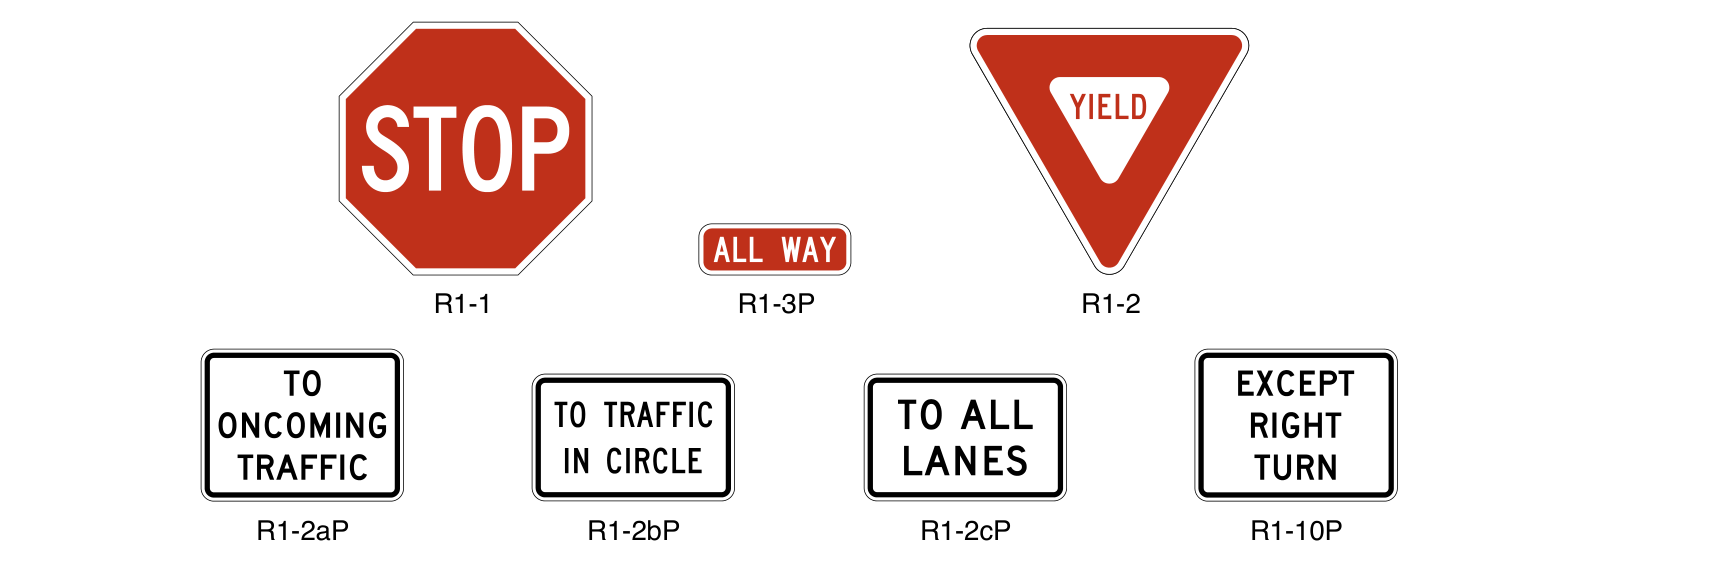

**[Image 3]** Table 7B-1 (p.971) — depicts R1-5A, R1-5C, R1-6, R1-6A, R1-6B, R1-6C, R1-9B, R1-9C, R2-1, R2-10, R2-11, R2-6AP, R2-6BP, R2-6P, W16-2AP, W16-2P, W16-5P, W16-6P, W16-7P, W16-9P  
*Table 7B-1. School Area Sign and Plaque Sizes*  
score=0.000

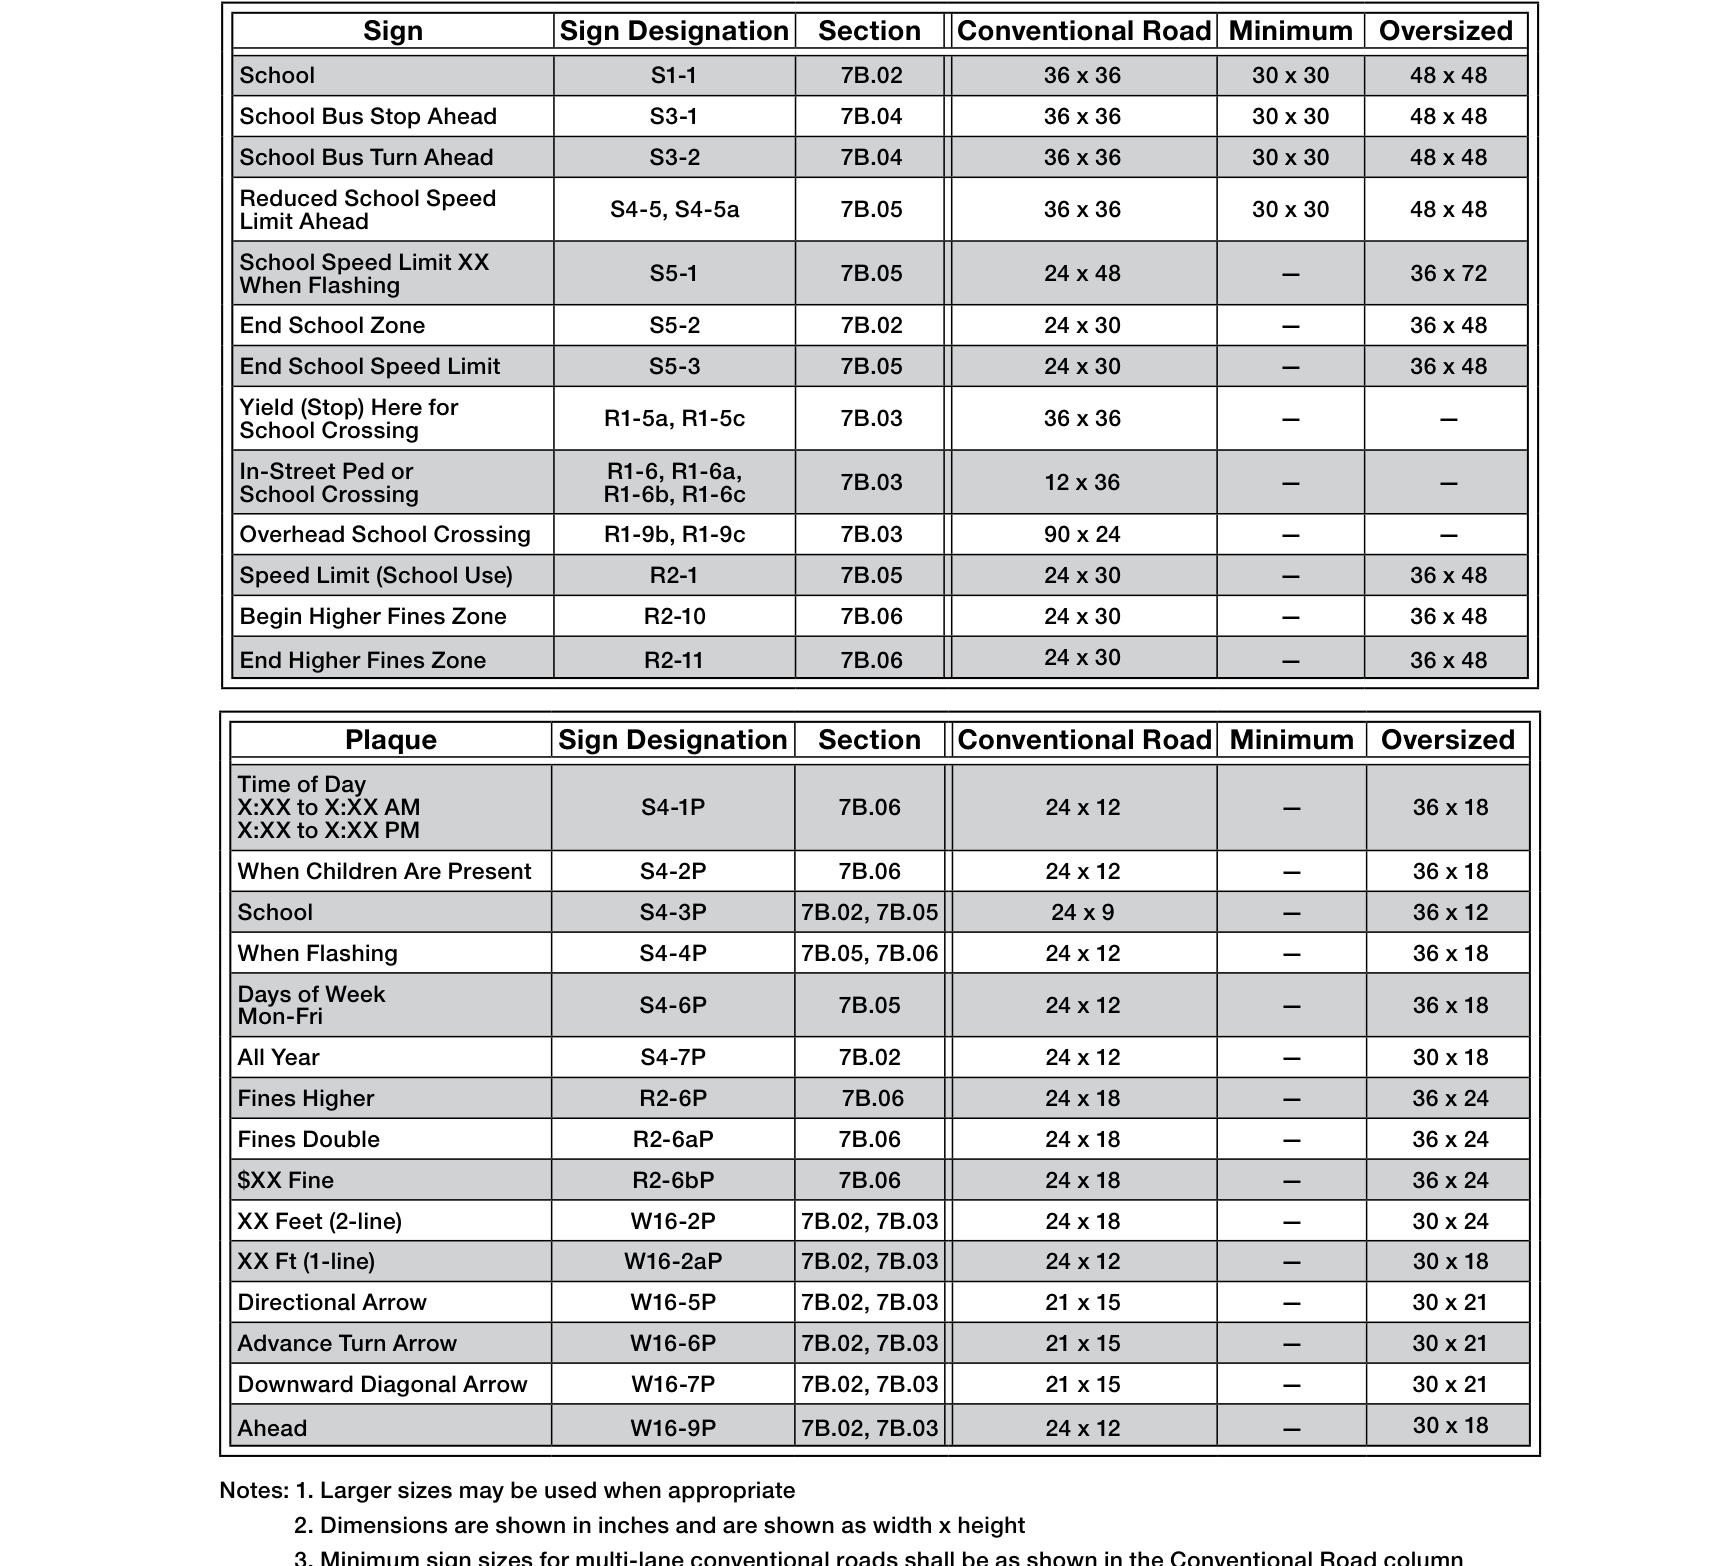

In [15]:
# TB009 is the regression to watch. It asks for four R2-1 sign sizes; gold
# evidence is Table 2B-1, which has 8 sheets. Under greedy allocation the model
# ABSTAINED — 0.00 correctness where it previously had full credit.
#
# Expect: several images, each labelled "[sheet N of M]", and an answer that
# actually lists the sizes.
_ = ask("What are the four sizes listed for the R2-1 Speed Limit sign?",
        show_scores=True)

## 6. Run the MUTCD-150 benchmark

150 questions against the current config. Pick the model first — every row
you intend to compare must use the **same** model.


In [17]:
!pip install -q anthropic
import anthropic; print("anthropic", anthropic.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.1 MB/s eta 0:00:00
anthropic 1.4.0


In [19]:
import os
k = os.environ.get("ANTHROPIC_API_KEY", "")
print("present      :", bool(k))
print("length       :", len(k))
print("prefix       :", k[:7] if k else "-")          # expect sk-ant-
print("whitespace   :", k != k.strip())               # must be False
print("quotes       :", k[:1] in "\"'" or k[-1:] in "\"'")
print("newline      :", "\n" in k or "\r" in k)

present      : True
length       : 108
prefix       : sk-ant-
whitespace   : False
quotes       : False
newline      : False


In [22]:
import os
k = os.environ["ANTHROPIC_API_KEY"]
print("segment  :", k.split("-")[2] if len(k.split("-")) > 2 else "?")   # expect: api03
print("non-ascii:", [c for c in k if not (32 <= ord(c) < 127)])          # expect: []

segment  : api03
non-ascii: []


In [25]:
import anthropic, os
c = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
try:
    r = c.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=20,
        messages=[{"role": "user", "content": "say ok"}],
    )
    print("KEY WORKS:", r.content[0].text)
except Exception as e:
    print(type(e).__name__, e)

KEY WORKS: ok


In [28]:
# Drop cached API clients so they rebuild with the current key.
p = pipeline
p.vlm._anthropic_clients.clear()
p.vlm._api_clients.clear()
print("cleared")

# Prove it works through the pipeline, not just the bare SDK.
#from mrag.ask import ask
#_ = ask("What shape and colour is a STOP sign?")

cleared


In [26]:
CFG.set_vlm_model("frontier_claude")   # or frontier_qwen

'claude-fable-5'

In [29]:
# The runner is a Python API, not a CLI.
import sys
REPO = "/content/Beyond_RAG_repo"
sys.path.insert(0, f"{REPO}/benchmarks/mutcd150/v1")

from mutcd_benchmark_runner import run_benchmark
from mrag.ask import ask
from mrag.config import CFG

BENCH = f"{REPO}/benchmarks/mutcd150/v1/mutcd_benchmark_questions_v1.jsonl"
OUT   = CFG.base_dir / "benchmark_runs"          # Drive/MyDrive/Beyond_RAG/benchmark_runs

paths = run_benchmark(
    CFG=CFG,
    ask_fn=ask,
    questions_path=BENCH,
    output_root=OUT,
    run_id="beyond_rag_002_roundrobin",          # NEW id — 001 used greedy allocation
    models=[{"alias": "fable", "selector": "frontier_claude", "provider": "anthropic"}],
    prompt_style="fewshot",

    # Smoke-test the regression first. Run these three, check TB009 answers
    # instead of abstaining, THEN comment this line out for the full 150.
    question_ids=["TB008", "TB009", "TB026"],

    resume=True,
)
for k, v in paths.items():
    print(f"{k:<24} {v}")


=== Model 'fable' (selector='fable') ===
[1/150] RUN  fable T001 r1
  OK 9933 ms — 1494 chars
[2/150] RUN  fable T002 r1
  OK 12399 ms — 2168 chars
[3/150] RUN  fable T003 r1
  OK 8870 ms — 1852 chars
[4/150] RUN  fable T004 r1
  OK 7373 ms — 1139 chars
[5/150] RUN  fable T005 r1
  OK 14103 ms — 2355 chars
[6/150] RUN  fable T006 r1
  OK 14097 ms — 2457 chars
[7/150] RUN  fable T007 r1
  OK 9037 ms — 1603 chars
[8/150] RUN  fable T008 r1
  OK 8905 ms — 1559 chars
[9/150] RUN  fable T009 r1
  OK 10364 ms — 2562 chars
[10/150] RUN  fable T010 r1
  OK 10233 ms — 1882 chars
[11/150] RUN  fable T011 r1
  OK 10810 ms — 2084 chars
[12/150] RUN  fable T012 r1
  OK 9487 ms — 2302 chars
[13/150] RUN  fable T013 r1
  OK 8562 ms — 1538 chars
[14/150] RUN  fable T014 r1
  OK 9121 ms — 1725 chars
[15/150] RUN  fable T015 r1
  OK 8280 ms — 1303 chars
[16/150] RUN  fable T016 r1
  OK 37020 ms — 4159 chars
[17/150] RUN  fable T017 r1
  OK 9489 ms — 1974 chars
[18/150] RUN  fable T018 r1
  OK 7782 ms —

  OK 20511 ms — 1060 chars
[54/150] RUN  fable T054 r1
  OK 9955 ms — 636 chars
[55/150] RUN  fable T055 r1
  OK 8378 ms — 727 chars
[56/150] RUN  fable T056 r1
  OK 15280 ms — 2273 chars
[57/150] RUN  fable T057 r1
  OK 8972 ms — 1453 chars
[58/150] RUN  fable T058 r1
  OK 23155 ms — 1478 chars
[59/150] RUN  fable T059 r1
  OK 7301 ms — 611 chars
[60/150] RUN  fable T060 r1
  OK 10147 ms — 811 chars
[61/150] RUN  fable TB001 r1
  OK 9599 ms — 1719 chars
[62/150] RUN  fable TB002 r1
  OK 16215 ms — 1035 chars
[63/150] RUN  fable TB003 r1
  OK 11095 ms — 1444 chars
[64/150] RUN  fable TB004 r1
  OK 12649 ms — 1945 chars
[65/150] RUN  fable TB005 r1
  OK 13720 ms — 2118 chars
[66/150] RUN  fable TB006 r1
  OK 13571 ms — 2392 chars
[67/150] RUN  fable TB007 r1
  OK 14077 ms — 2220 chars
[68/150] RUN  fable TB008 r1
  OK 17272 ms — 952 chars
[69/150] RUN  fable TB009 r1
  OK 11370 ms — 1071 chars
[70/150] RUN  fable TB010 r1
  OK 21585 ms — 2126 chars
[71/150] RUN  fable TB011 r1
  OK 1448

  OK 21075 ms — 1141 chars
[90/150] RUN  fable TB030 r1
  OK 10248 ms — 1088 chars
[91/150] RUN  fable F001 r1
  OK 12374 ms — 2122 chars
[92/150] RUN  fable F002 r1
  OK 13973 ms — 1798 chars
[93/150] RUN  fable F003 r1
  OK 9486 ms — 1149 chars
[94/150] RUN  fable F004 r1
  OK 14155 ms — 1433 chars
[95/150] RUN  fable F005 r1
  OK 8130 ms — 746 chars
[96/150] RUN  fable F006 r1
  OK 39566 ms — 899 chars
[97/150] RUN  fable F007 r1
  OK 19576 ms — 1745 chars
[98/150] RUN  fable F008 r1
  OK 8881 ms — 1416 chars
[99/150] RUN  fable F009 r1
  OK 16285 ms — 364 chars
[100/150] RUN  fable F010 r1
  OK 18857 ms — 974 chars
[101/150] RUN  fable F011 r1
  OK 8480 ms — 1059 chars
[102/150] RUN  fable F012 r1
  OK 9623 ms — 1273 chars
[103/150] RUN  fable F013 r1
  OK 19515 ms — 1565 chars
[104/150] RUN  fable F014 r1
  OK 12651 ms — 2254 chars
[105/150] RUN  fable F015 r1
  OK 10673 ms — 2062 chars
[106/150] RUN  fable F016 r1
  OK 11840 ms — 2098 chars
[107/150] RUN  fable F017 r1
  OK 12777

  OK 16111 ms — 1847 chars
[141/150] RUN  fable M021 r1
  OK 11137 ms — 1925 chars
[142/150] RUN  fable M022 r1
  OK 18476 ms — 3645 chars
[143/150] RUN  fable M023 r1
  OK 35948 ms — 3567 chars
[144/150] RUN  fable M024 r1
  OK 24831 ms — 3217 chars
[145/150] RUN  fable M025 r1
  OK 7724 ms — 863 chars
[146/150] RUN  fable M026 r1
  OK 7479 ms — 823 chars
[147/150] RUN  fable M027 r1
  OK 5823 ms — 482 chars
[148/150] RUN  fable M028 r1
  OK 13974 ms — 653 chars
[149/150] RUN  fable M029 r1
  OK 5422 ms — 408 chars
[150/150] RUN  fable M030 r1
  OK 6401 ms — 562 chars

Run complete
 answers : /content/drive/MyDrive/MRAG/benchmark_runs/beyond_rag_001/answers_beyond_rag_001.jsonl
 retrieval: /content/drive/MyDrive/MRAG/benchmark_runs/beyond_rag_001/retrieval_beyond_rag_001.jsonl
 manifest: /content/drive/MyDrive/MRAG/benchmark_runs/beyond_rag_001/manifest_beyond_rag_001.json
 errors  : /content/drive/MyDrive/MRAG/benchmark_runs/beyond_rag_001/errors_beyond_rag_001.jsonl
run_dir         

## 7. Ablations

Six configs live in `ablations/configs/`: router, VLM figure filter, graph
proximity, rule-type weight, hierarchy prior, reranker. Results land in
`ablations/results/`, which ships empty.


In [ ]:
!ls /content/Beyond_RAG_repo/ablations/configs

# NOTE: all six ablations were already run and graded — 900 records, in the
# per-response grading rationales. Published full-credit rates:
#
#   baseline 80.0 | A1 no-router 76.0 | A2 no-VLM-filter 74.7
#   A3 no-graph 76.0 | A4 no-rule-type 74.7 | A5 no-hierarchy 72.7
#   A6 no-reranker 68.7
#
# Only A2, A5 and A6 appear in the submitted paper. A3 (graph) and A4
# (rule type) are the two a reviewer will ask about, and they exist.
#
# Re-run one only if the pipeline changes underneath it:
# !cd /content/Beyond_RAG_repo && python ablations/run_ablation.py \
#     --ablation A3_no_graph --retrieval-only \
#     --output ablations/results/A3_no_graph.json

## 8. Debug retrieval without calling the VLM

In [ ]:
from mrag.retrieval import Retriever

res = pipeline.retriever.retrieve("STOP sign sizes at an all-way stop")

print(f"{len(res.chunks)} chunks\n")
for c in res.chunks:
    print(f"  {c.get('section_id'):<10} {c.get('content_type'):<9} "
          f"p.{c.get('page_printed'):<5} score={c.get('score', 0):.3f}")

print(f"\n{len(res.figures)} figures")
for f in res.figures:
    n = len(f.get("image_paths") or [])
    print(f"  {f.get('figure_id'):<16} sheets={n:<3} source={f.get('source','?')}")

## 9. Inspect the knowledge graph

In [ ]:
import collections
kg = pipeline.kg
print(kg.g.number_of_nodes(), "nodes,", kg.g.number_of_edges(), "edges")
print()
print("node kinds:")
for k, v in collections.Counter(d.get("kind", "?") for _, d in kg.g.nodes(data=True)).most_common():
    print(f"  {k:<14} {v}")
print()
print("edge labels:")
for k, v in collections.Counter(d.get("label", "?") for *_, d in kg.g.edges(data=True)).most_common():
    print(f"  {k:<20} {v}")

In [ ]:
# Sections cross-referenced by a given section (cites_section edges).
target = "4K.04"
refs = set()
for c in (json.loads(l) for l in open(CFG.chunks_jsonl) if l.strip()):
    if c["section_id"] == target:
        refs.update(c.get("section_refs") or [])
print(f"{target} cross-references: {sorted(refs)}")